# Exploratory Data Analysis


# IMPORT NECESSARY LIBRARIES AND .CSV FILE FROM GOOGLE DRIVE

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

!pip install kaggle
from google.colab import files
files.upload() # upload kaggle.json (Kaggle API key)

!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json



# Download the Spotify dataset from Kaggle
!kaggle datasets download -d nelgiriyewithana/top-spotify-songs-2023
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
# Unzip the downloaded dataset
!unzip top-spotify-songs-2023.zip

# Remove the zip file to clean up
!rm top-spotify-songs-2023.zip

spotify_2023 = pd.read_csv('spotify-2023.csv',encoding='ISO-8859-1')

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/nelgiriyewithana/top-spotify-songs-2023
License(s): other
  0% 0.00/47.1k [00:00<?, ?B/s]
100% 47.1k/47.1k [00:00<00:00, 64.4MB/s]
Archive:  top-spotify-songs-2023.zip
  inflating: spotify-2023.csv        


# TEST

In [ ]:
display(spotify_2023.head(5))

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


# 1. OVERVIEW OF THE DATASET

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')

# 1. Overview of the Dataset

# Create a table summarizing the dataset
dataset_overview = pd.DataFrame({
    'Column Name': df.columns,
    'Data Type': df.dtypes.values,
    'Missing Values': df.isnull().sum().values,
    'Non-Null Count': df.notnull().sum().values
})

# Display the number of rows and columns
num_rows, num_columns = df.shape
print(f"Number of Rows: {num_rows}")
print(f"Number of Columns: {num_columns}\n")

# Display the dataset overview table
print("Overview of the Dataset:")
print(dataset_overview)



Number of Rows: 953
Number of Columns: 24

Overview of the Dataset:
             Column Name Data Type  Missing Values  Non-Null Count
0             track_name    object               0             953
1         artist(s)_name    object               0             953
2           artist_count     int64               0             953
3          released_year     int64               0             953
4         released_month     int64               0             953
5           released_day     int64               0             953
6   in_spotify_playlists     int64               0             953
7      in_spotify_charts     int64               0             953
8                streams    object               0             953
9     in_apple_playlists     int64               0             953
10       in_apple_charts     int64               0             953
11   in_deezer_playlists    object               0             953
12      in_deezer_charts     int64               0           

1. **How many rows and columns does the dataset contain?**

The dataset contains 953 rows and 24 columns.

**What are the data types of each column? Are there any missing values?**

**Data types:**

**Object (string)**: track_name, artist(s)_name, streams, in_deezer_playlists, in_shazam_charts, key, mode
***Integer (int64):*** artist_count, released_year, released_month, released_day, in_spotify_playlists, in_spotify_charts, in_apple_playlists, in_apple_charts, in_deezer_charts, bpm, danceability_%, valence_%, energy_%, acousticness_%, instrumentalness_%, liveness_%, speechiness_%

**Missing values:**

The column in_shazam_charts has 50 missing values.
The column key has 95 missing values.
All other columns have no missing values.

# 2. Basic Descriptive Statistics

Mean streams: 514137424.93907565
Median streams: 290530915.0
Standard Deviation of streams: 566856949.038883


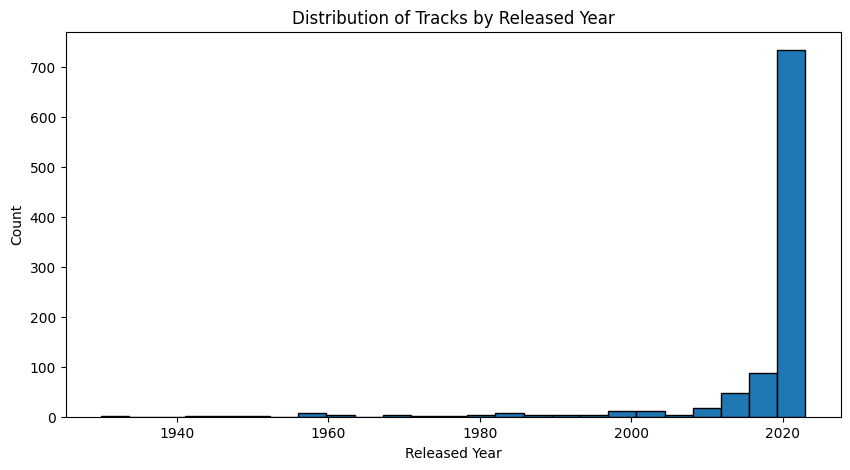

Distribution of artist count:
artist_count
1    587
2    254
3     85
4     15
5      5
6      3
8      2
7      2
Name: count, dtype: int64


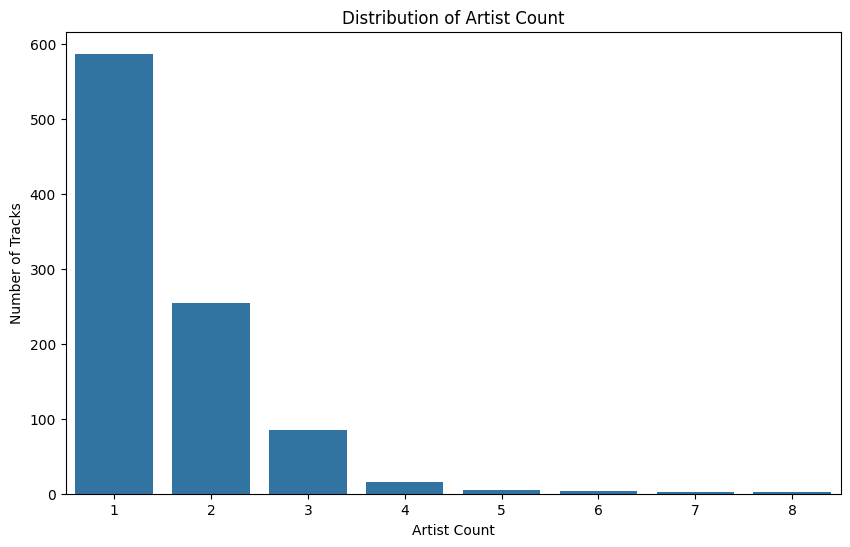

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')

# Convert 'streams' column to numeric (in case it is stored as object type)
df['streams'] = pd.to_numeric(df['streams'], errors='coerce')

# 1. Calculate the mean, median, and standard deviation of the 'streams' column
mean_streams = df['streams'].mean()
median_streams = df['streams'].median()
std_streams = df['streams'].std()

print(f"Mean streams: {mean_streams}")
print(f"Median streams: {median_streams}")
print(f"Standard Deviation of streams: {std_streams}")

# 2. Distribution of 'released_year' and 'artist_count'
# Plot the distribution of the 'released_year' column using a histogram
# The 'bins' parameter defines the number of bars in the histogram, and 'edgecolor' gives each bar a black outline
plt.figure(figsize=(10, 5))  # Set the figure size
plt.hist(spotify_2023['released_year'], bins=25, edgecolor='black')  # Create the histogram
plt.title('Distribution of Tracks by Released Year')  # Add a title to the plot
plt.xlabel('Released Year')  # Label the x-axis
plt.ylabel('Count')  # Label the y-axis
plt.show()  # Display the plot
artist_count_distribution = df['artist_count'].value_counts()  # Counts of number of tracks by artist count
print("Distribution of artist count:")
print(artist_count_distribution)

# Visualize the distributions for better understanding (using matplotlib or seaborn)
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of 'artist_count'
plt.figure(figsize=(10, 6))
sns.countplot(x='artist_count', data=df)
plt.title('Distribution of Artist Count')
plt.xlabel('Artist Count')
plt.ylabel('Number of Tracks')
plt.show()


2. What are the mean, median, and standard deviation of the streams column?

Mean streams: 514,137,424.94 (approximately 514 million)

Median streams: 290,530,915 (approximately 291 million)

Standard deviation of streams: 566,856,949.04 (approximately 567 million)

***This means that, on average, the tracks in the dataset have about 514 million streams, but the large standard deviation suggests that there is considerable variation in the number of streams between tracks. The median of 291 million streams indicates that half of the tracks have streams below this number, showing that the dataset likely contains some extremely popular tracks with very high stream counts, pulling the mean upward.***

What is the distribution of released_year and artist_count? Are there any noticeable trends
or outliers?
Distribution of released_year:

The dataset contains tracks released from 1930 to 2023, with notable increases in more recent years.

The year 2022 has the highest number of track releases, with 402 tracks, followed by 2023 with 175 tracks.

Other significant years include 2021 (119 tracks) and 2019 (36 tracks).

Older years (e.g., 1930 to 1999) have very few tracks, often just 1-5 tracks per year.

***This trend indicates that the majority of tracks in this dataset were released in the last decade, with a particular spike from 2021 to 2023. This could be due to the increasing popularity of streaming platforms like Spotify in more recent years.***

Distribution of artist_count:

587 tracks are performed by a single artist.

254 tracks are performed by two artists (likely collaborations or duets).

There are fewer tracks with higher artist counts, with just 85 tracks involving three artists and only 2 tracks involving seven or eight artists

***This distribution suggests that most popular tracks in the dataset are performed by solo artists or small collaborations of 2-3 artists.***


# 3. Top Performers

Track with the highest streams: Blinding Lights with 3703895074.0 streams.
Top 5 most streamed tracks:
                                   track_name      streams
                              Blinding Lights 3703895074.0
                                 Shape of You 3562543890.0
                            Someone You Loved 2887241814.0
                                 Dance Monkey 2864791672.0
Sunflower - Spider-Man: Into the Spider-Verse 2808096550.0


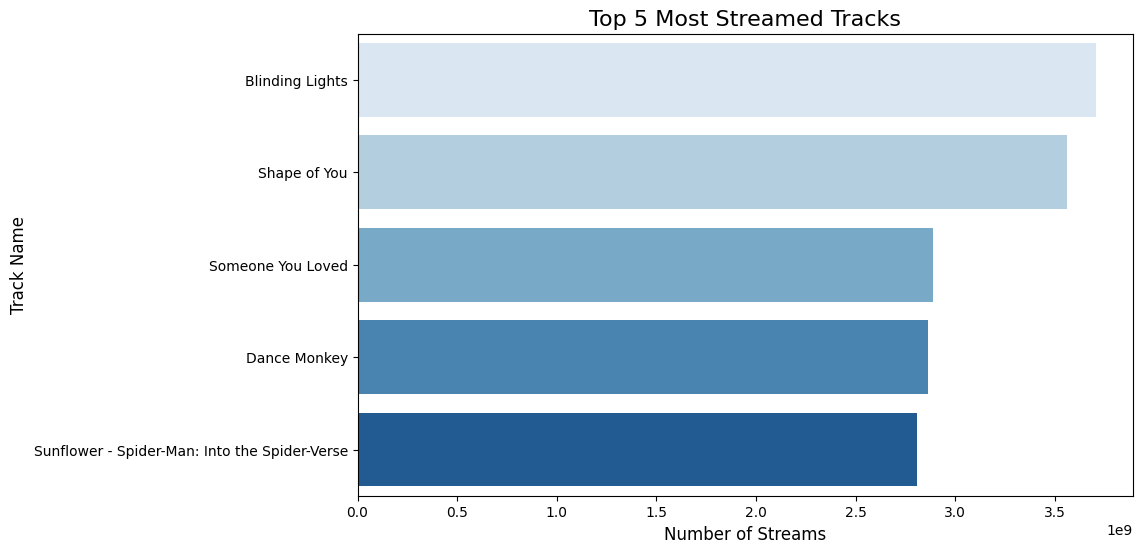


Top 5 most frequent artists based on the number of tracks:
artist(s)_name
Taylor Swift    34
The Weeknd      22
Bad Bunny       19
SZA             19
Harry Styles    17
Name: count, dtype: int64


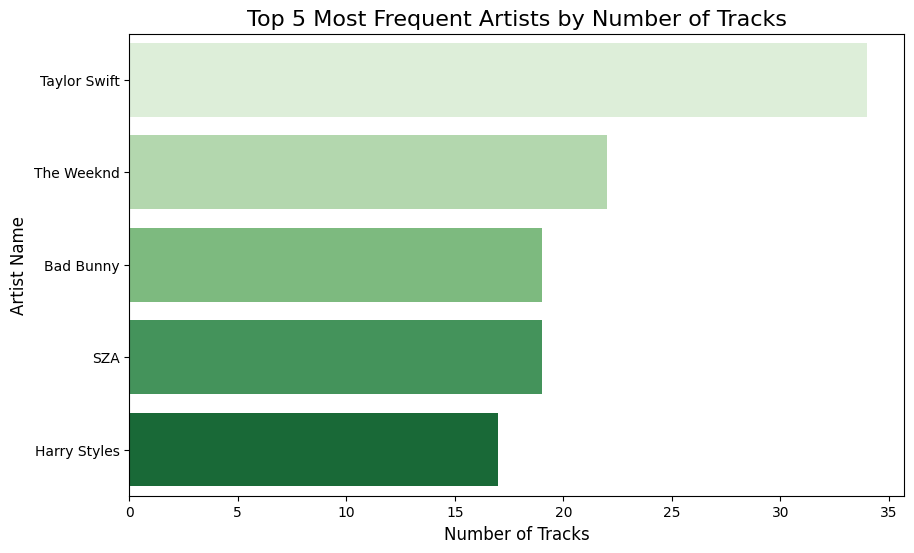

In [ ]:
#3
import matplotlib.pyplot as plt #plotting library used to create static, animated, and interactive visualizations in Python.
import seaborn as sns           #data visualization library for easier interface

# 1. Track with the highest number of streams
top_track = df[['track_name', 'streams']].sort_values(by='streams', ascending=False).iloc[0] #selects two columns from the DataFrame,Sorts the data by the 'streams' column in descending order and after sorting, this selects the first row.
print(f"Track with the highest streams: {top_track['track_name']} with {top_track['streams']} streams.")

# 2. Top 5 most streamed tracks
top_5_tracks = df[['track_name', 'streams']].sort_values(by='streams', ascending=False).head(5) #returns the top 5 rows after sorting the data by 'streams' in descending order, giving the 5 most-streamed tracks.
print("Top 5 most streamed tracks:")
print(top_5_tracks.to_string(index=False)) #Converts the DataFrame to a string for clean printing, without showing the index.

# Plot for Top 5 Most Streamed Tracks using 'hue' and setting 'legend=False'
plt.figure(figsize=(10, 6))
sns.barplot(x='streams', y='track_name', data=top_5_tracks, hue='track_name', palette='Blues', dodge=False, legend=False)
plt.title('Top 5 Most Streamed Tracks', fontsize=16)
plt.xlabel('Number of Streams', fontsize=12)
plt.ylabel('Track Name', fontsize=12)
plt.show()

# 3. Top 5 most frequent artists based on the number of tracks
top_5_artists = df['artist(s)_name'].value_counts().head(5) #Counts the number of occurrences of each artist in the dataset and returns it as a Series,Returns the top 5 most frequent artists based on the number of tracks
print("\nTop 5 most frequent artists based on the number of tracks:")
print(top_5_artists)

# Convert the Series to DataFrame for plotting
top_5_artists_df = top_5_artists.reset_index() # Resets the index of the Series (which was based on the artist names) and converts it into a DataFrame.
top_5_artists_df.columns = ['artist_name', 'track_count'] #Renames the columns of the new DataFrame to 'artist_name' and 'track_count.'

# Plot for Top 5 Most Frequent Artists using 'hue' and setting 'legend=False'
plt.figure(figsize=(10, 6))
sns.barplot(x='track_count', y='artist_name', data=top_5_artists_df, hue='artist_name', palette='Greens', dodge=False, legend=False)
plt.title('Top 5 Most Frequent Artists by Number of Tracks', fontsize=16)
plt.xlabel('Number of Tracks', fontsize=12)
plt.ylabel('Artist Name', fontsize=12)
plt.show()


3. Which track has the highest number of streams? Display the top 5 most streamed tracks.  

Track with the highest streams:

Track Name: "Blinding Lights" by The Weeknd.
Number of Streams: 3,703,895,074 (over 3.7 billion streams).

**Blinding Lights** tops the list with over 3.7 billion streams, followed closely by **Shape of You** with 3.56 billion streams.
**Someone You Loved**, **Dance Monkey, and Sunflower** also have streams in the range of 2.8–2.9 billion, making them some of the most popular tracks globally.

**Taylor Swif**t has the most tracks in the dataset with **34 songs**, showcasing her prolific catalog and consistent popularity.
**The Weeknd comes second with 22 track**s, which complements his top position in terms of streams (with "Blinding Lights").
**Bad Bunny and SZA **are tied for third with** 19 tracks each,** indicating their wide appeal and presence in the music industry.
**Harry Styles** rounds out the top five with** 17 tracks**.

# 4. Temporal Trends

Number of Tracks Released Per Year:
    Year  Number of Tracks
0   1930                 1
1   1942                 1
2   1946                 1
3   1950                 1
4   1952                 1
5   1957                 2
6   1958                 3
7   1959                 2
8   1963                 3
9   1968                 1
10  1970                 2
11  1971                 1
12  1973                 1
13  1975                 2
14  1979                 1
15  1982                 2
16  1983                 1
17  1984                 4
18  1985                 2
19  1986                 2
20  1987                 1
21  1991                 2
22  1992                 1
23  1994                 1
24  1995                 2
25  1996                 1
26  1997                 1
27  1998                 1
28  1999                 5
29  2000                 4
30  2002                 6
31  2003                 2
32  2004                 4
33  2005                 1
34  2007           

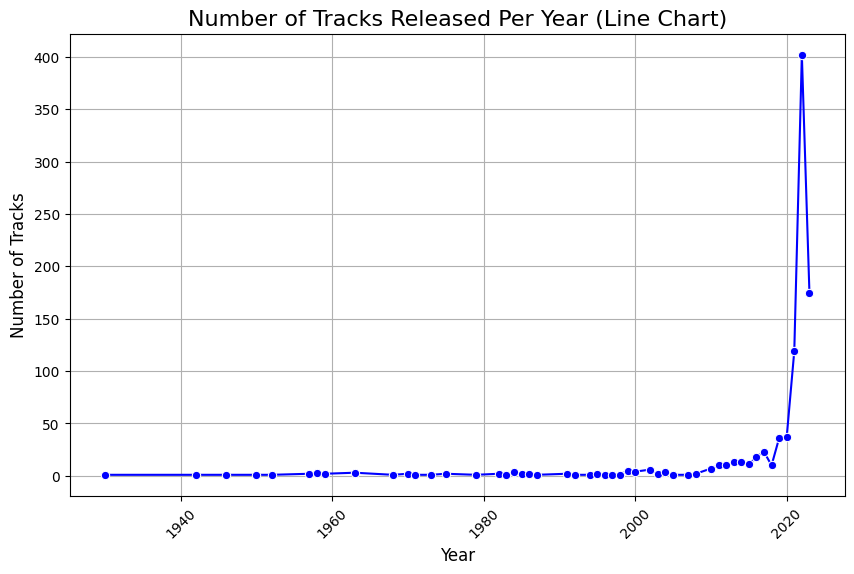


Number of Tracks Released Per Month:
        Month  Number of Tracks
0     January               134
1    February                61
2       March                86
3       April                66
4         May               128
5        June                86
6        July                62
7      August                46
8   September                56
9     October                73
10   November                80
11   December                75


<ipython-input-17-1432686ab510>:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=released_per_month.index, y=released_per_month.values, palette='Set3')


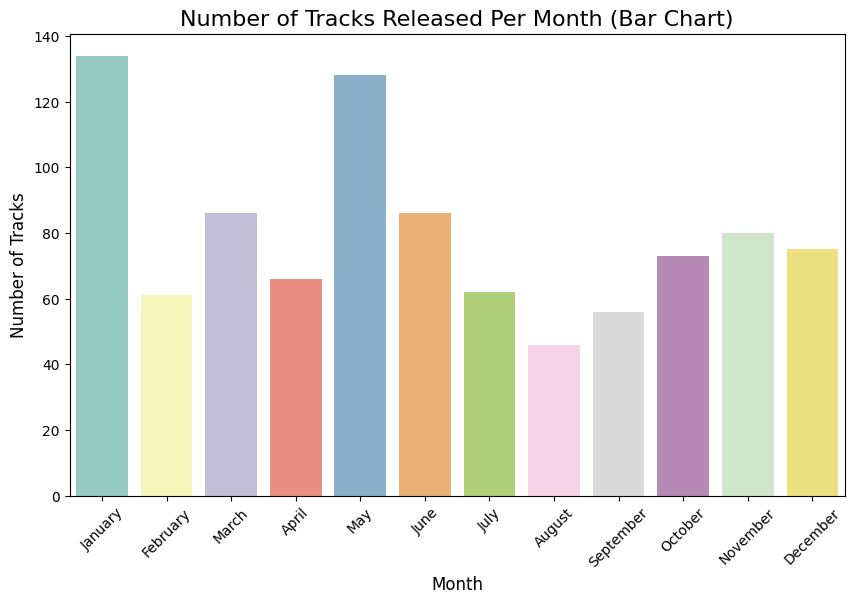


The month with the most releases is: January


In [ ]:
#4
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the dataset (assuming df is already loaded)
# df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')

# 1. Number of tracks released per year
released_per_year = df['released_year'].value_counts().sort_index() #extracts the column ,Counts how many tracks were released,sorts the results by the year, in ascending order.

# Convert to a table (DataFrame) for easy display
released_per_year_table = pd.DataFrame({
    'Year': released_per_year.index,
    'Number of Tracks': released_per_year.values
})

# Display the table
print("Number of Tracks Released Per Year:")
print(released_per_year_table)

# Extract the x (years) and y (number of tracks) values for graph
x_years = released_per_year.index
y_tracks = released_per_year.values

# Plot the line chart
plt.figure(figsize=(10, 6))
sns.lineplot(x=x_years, y=y_tracks, marker='o', color='blue')  # 'marker' adds dots at each data point
plt.title('Number of Tracks Released Per Year (Line Chart)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Tracks', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# 2. Map the numbers 1-12 to month names
month_mapping = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
    7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

# Apply the mapping to 'released_month'
df['released_month'] = df['released_month'].map(month_mapping)

# Number of tracks released per month
released_per_month = df['released_month'].value_counts().reindex(month_mapping.values(), fill_value=0)  # Ensure the correct month order

# Convert to a table (DataFrame) for easy display
released_per_month_table = pd.DataFrame({
    'Month': released_per_month.index,
    'Number of Tracks': released_per_month.values
})

# Display the table
print("\nNumber of Tracks Released Per Month:")
print(released_per_month_table)

# Plot the bar chart with different colors for each bar
plt.figure(figsize=(10, 6))
sns.barplot(x=released_per_month.index, y=released_per_month.values, palette='Set3')
plt.title('Number of Tracks Released Per Month (Bar Chart)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Tracks', fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Month with the most releases
most_releases_month = released_per_month.idxmax()
print(f"\nThe month with the most releases is: {most_releases_month}")



**4. Analyze the trends in the number of tracks released over time. Plot the number of tracks released per year.**


From the 1930s up to 1998, the number of tracks remained low, ranging from only 1 to 4 per year. However, starting in 1999 and into the early 2000s, the chart shows a noticeable rise in the number of tracks, especially in the 2010s. The most significant increase occurred in the 2020s, peaking in 2022 with 402 tracks.

**Does the number of tracks released per month follow any noticeable patterns? Which month sees the most releases?**

The month with the highest number of tracks released is January, with 134 tracks. May follows closely in second place with 128 tracks. All other months have fewer than 90 tracks, with August having the lowest count at only 46 tracks.

# 5. Genre and Music Characteristics

Correlation between streams and musical attributes:
                 streams       bpm  danceability_%  energy_%
streams         1.000000 -0.002438       -0.105457 -0.026051
bpm            -0.002438  1.000000       -0.147095  0.025794
danceability_% -0.105457 -0.147095        1.000000  0.198095
energy_%       -0.026051  0.025794        0.198095  1.000000


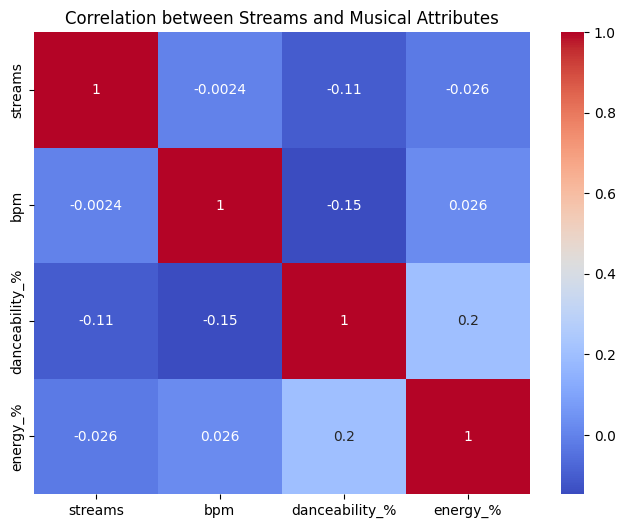

Correlation between danceability and energy: 0.19809484837625718
Correlation between valence and acousticness: -0.08190727483082759


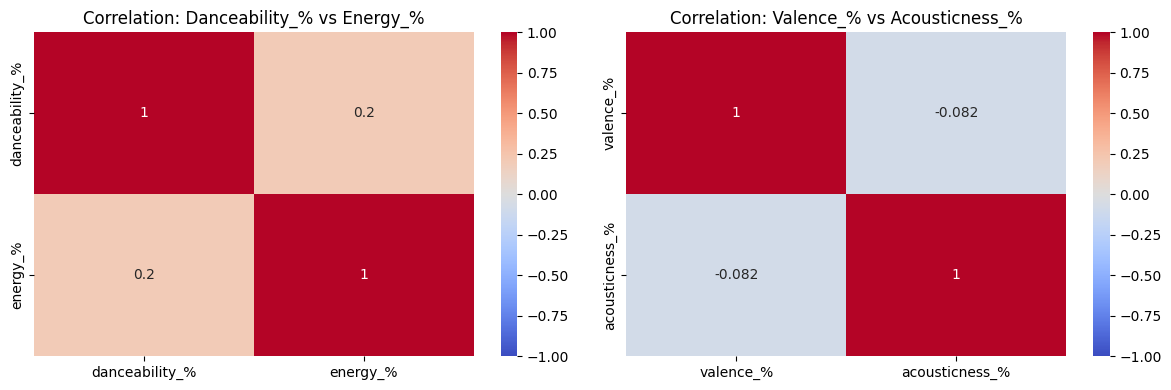

In [ ]:
#5
# Correlation between streams and musical attributes like bpm, danceability, and energy
correlation_matrix = df[['streams', 'bpm', 'danceability_%', 'energy_%']].corr()
print("Correlation between streams and musical attributes:")
print(correlation_matrix)

# Plot the correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation between Streams and Musical Attributes')
plt.show()

# Correlation between danceability and energy
dance_energy_corr = df['danceability_%'].corr(df['energy_%'])
print(f"Correlation between danceability and energy: {dance_energy_corr}")

# Correlation between valence and acousticness
valence_acousticness_corr = df['valence_%'].corr(df['acousticness_%'])
print(f"Correlation between valence and acousticness: {valence_acousticness_corr}")

# Define the subplots with a 1x2 layout (1 row and 2 columns)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))  # Set the size of the figure

# Analyze the correlation between 'danceability_%' and 'energy_%'
columns_of_interest = ['danceability_%', 'energy_%']  # Select the relevant columns
correlation_matrix = spotify_2023[columns_of_interest].corr()  # Calculate the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axs[0])
# Create a heatmap for the first set of variables with annotations and a color map
axs[0].set_title('Correlation: Danceability_% vs Energy_%')  # Set the title for the first subplot

# Analyze the correlation between 'valence_%' and 'acousticness_%'
columns_of_interest = ['valence_%', 'acousticness_%']  # Select the relevant columns
correlation_matrix = spotify_2023[columns_of_interest].corr()  # Calculate the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axs[1])
# Create a heatmap for the second set of variables with annotations and a color map
axs[1].set_title('Correlation: Valence_% vs Acousticness_%')  # Set the title for the second subplot

# Adjust the layout to ensure the subplots fit well within the figure
plt.tight_layout()

# Display the subplots
plt.show()


  **5. Examine the correlation between streams and musical attributes like bpm, danceability_%, and energy_%. Which attributes seem to influence streams the most?**

After analyzing the correlation heatmap and the rest of the output, it shows that the correlation between **streams and each of the musical attributes (bpm, danceability, and energy) is weak and negativ**e, indicating **little to no relationship** between them. The correlation between **streams and bpm is -0.0024**, between **streams and danceability is -0.11**, and between **streams and energy is -0.026** . Although the results suggest that none of the three musical attributes strongly influence the number of streams, **bpm** appears to have the most influence among them.


**Is there a correlation between danceability_% and energy_%? How about valence_% and acousticness_%?**

The correlation between **danceability and energy is 0.1981**, which is a **weak positive** correlation. This shows that tracks with higher danceability has slightly more energy. However, the relationship between the two musical attribute is not strong. On the other hand, the correlation between **valence and acousticness is -0.0819** . It has a weak negative correlation. This shows that the two has little to no relationship between them.

# 6. Platform Popularity

,track_name,artist(s)_name,released_year,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists
Index,,,,,,,
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2023,553,147,141381703,43
1,LALA,Myke Towers,2023,1474,48,133716286,48
2,vampire,Olivia Rodrigo,2023,1397,113,140003974,94
3,Cruel Summer,Taylor Swift,2019,7858,100,800840817,116
4,WHERE SHE GOES,Bad Bunny,2023,3133,50,303236322,84
5,Sprinter,"Dave, Central Cee",2023,2186,91,183706234,67
6,Ella Baila Sola,"Eslabon Armado, Peso Pluma",2023,3090,50,725980112,34
7,Columbia,Quevedo,2023,714,43,58149378,25
8,fukumean,Gunna,2023,1096,83,95217315,60


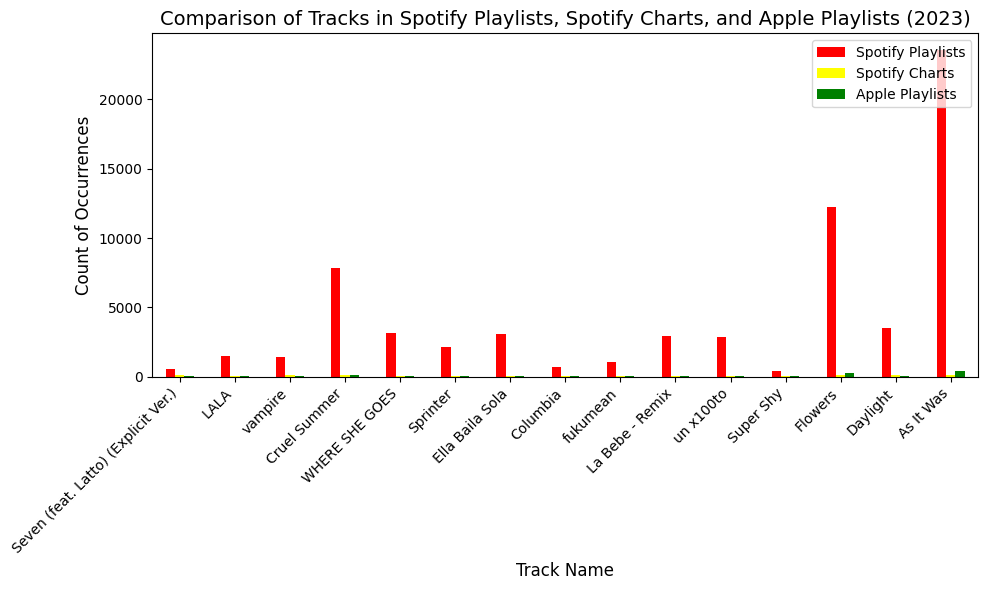

Track counts by platform:
in_spotify_playlists    4955719
in_spotify_charts         11445
in_apple_playlists        64625
dtype: int64


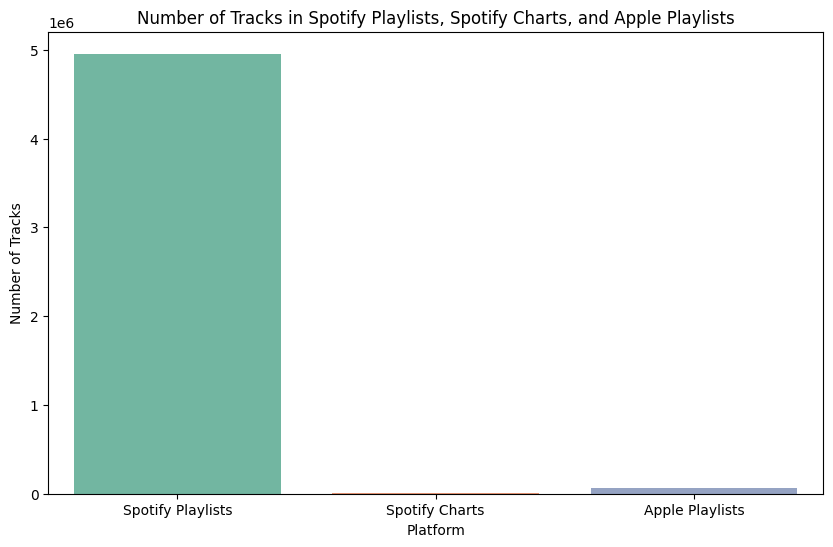

The platform that favors the most popular tracks is: in_spotify_playlists


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv('spotify-2023.csv', encoding='ISO-8859-1')

# Select specific columns to display relevant information about the tracks
columns_to_display = ['track_name', 'artist(s)_name', 'released_year', 'in_spotify_playlists',
                      'in_spotify_charts', 'streams', 'in_apple_playlists']

# Display the first 15 rows of the selected columns, resetting the index and renaming the axis
spotify_2023_released = df[columns_to_display]
display(spotify_2023_released.head(15).reset_index(drop=True).rename_axis('Index'))

# Select specific columns to display for the top 15 tracks
columns_to_display_top15 = ['track_name', 'artist(s)_name', 'in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists']

# Get the first 15 rows of the selected columns and reset the index
spotify_2023_top15 = df[columns_to_display_top15].head(15).reset_index(drop=True)

# Set the 'track_name' as the index for easier plotting
spotify_2023_top15.set_index('track_name', inplace=True)

# Plotting a comparative bar chart for the selected tracks
spotify_2023_top15[['in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists']].plot(
    kind='bar',
    figsize=(10, 6),
    color=['red', 'yellow', 'green']
)

# Adding titles and labels to the plot for clarity
plt.title('Comparison of Tracks in Spotify Playlists, Spotify Charts, and Apple Playlists (2023)', fontsize=14)
plt.xlabel('Track Name', fontsize=12)  # Label for the x-axis
plt.ylabel('Count of Occurrences', fontsize=12)  # Label for the y-axis
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability

# Display the legend to identify the data series
plt.legend(['Spotify Playlists', 'Spotify Charts', 'Apple Playlists'], loc='upper right')

# Adjust the layout to ensure everything fits well within the figure
plt.tight_layout()

# Display the plot
plt.show()

# Group the data by the number of tracks (for each track)
track_counts = df[['in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists']].sum()

# Compare tracks across spotify_playlists, spotify_charts, and apple_playlists
platform_track_counts = df[['in_spotify_playlists', 'in_spotify_charts', 'in_apple_playlists']].sum()
print("Track counts by platform:")
print(platform_track_counts)

# Create a DataFrame for visualization
platform_data = pd.DataFrame({
    'Platform': ['Spotify Playlists', 'Spotify Charts', 'Apple Playlists'],
    'Track Counts': [track_counts['in_spotify_playlists'], track_counts['in_spotify_charts'], track_counts['in_apple_playlists']]
})

# Plot the data (assign x to hue and disable legend to avoid warnings)
plt.figure(figsize=(10, 6))
sns.barplot(x='Platform', y='Track Counts', hue='Platform', data=platform_data, palette='Set2', dodge=False, legend=False)
plt.title('Number of Tracks in Spotify Playlists, Spotify Charts, and Apple Playlists')
plt.xlabel('Platform')
plt.ylabel('Number of Tracks')
plt.show()

# Platform favoring most popular tracks
most_popular_platform = platform_track_counts.idxmax()
print(f"The platform that favors the most popular tracks is: {most_popular_platform}")


**6. How do the numbers of tracks in spotify_playlists, spotify_charts, and apple_playlists compare? Which platform seems to favor the most popular tracks?**

Spotify playlist has far more number of tracks than the other two. Looking at the chart it really shows how far apart the top platform to the spotify charts and apple playlist. The spotify playlist has 4,955,719, spotify charts has 11,445, and apple playlists has 64,625. The platform that seems to favor the most popular tracks is spotify playlist.

# 7. Advanced Analysis

0
0


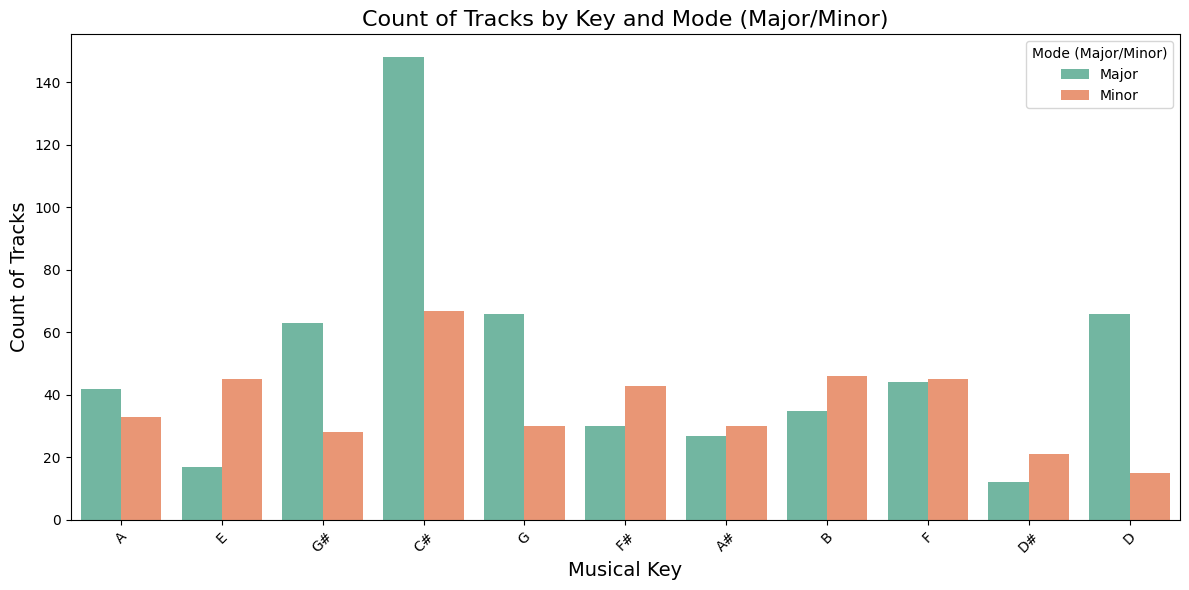

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Checking the null values in keys
print(spotify_2023['key'].isna().sum()) #counts the number of null entries.
# Filling the null values in keys with 'C#' as a placeholder
spotify_2023['key'] = spotify_2023['key'].fillna('C#') #The missing values in the 'key' column are filled with 'C#' (C-sharp) as a placeholder.

# Filtering to get the top 20 tracks by streams and with non-null key and mode
pattern_key_modes = spotify_2023[(spotify_2023['track_name'].notna()) &
                                 (spotify_2023['key'].notna()) &
                                 (spotify_2023['mode'].notna())].sort_values(by='streams', ascending=False)
                                 #This line filters the DataFrame to include only tracks where the track_name, key, and mode are not missing (.notna())
                                 #It then sorts the DataFrame in descending order by the streams column, to get the most-streamed tracks at the top.
                                 # The resulting DataFrame pattern_key_modes contains tracks with valid
# track_name, key, and mode values, sorted by streams.

# Checking the null values in keys
print(pattern_key_modes['key'].isna().sum())

# Plotting the count of tracks by key and mode in a single graph
plt.figure(figsize=(12, 6))
sns.countplot(x='key', data=pattern_key_modes, hue='mode', palette='Set2')

# Add titles and labels
plt.title('Count of Tracks by Key and Mode (Major/Minor)', fontsize=16)
plt.xlabel('Musical Key', fontsize=14)
plt.ylabel('Count of Tracks', fontsize=14)

# Rotate x-ticks for better readability
plt.xticks(rotation=45)

# Show the legend
plt.legend(title='Mode (Major/Minor)', loc='upper right')

# Display the plot
plt.tight_layout()
plt.show()


7. Based on the streams data, can you identify any patterns among tracks with the same key
or mode (Major vs. Minor)?

Based on the streams data, tracks in the key of C#, regardless of mode, received the highest number of streams. Additionally, major keys, in general, attracted significantly more streams compared to minor keys.

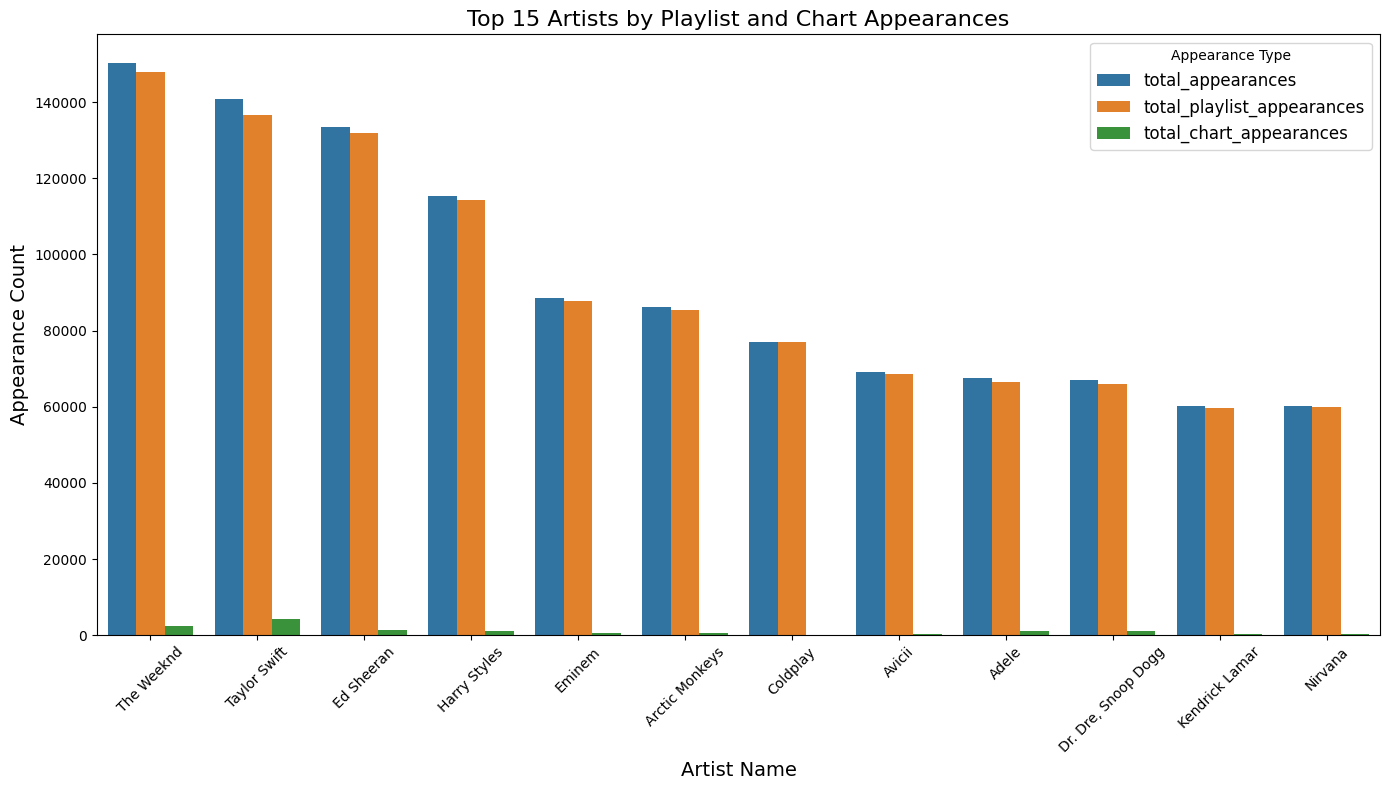

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define columns for playlists and charts to analyze their appearances
playlist_cols = ['in_spotify_playlists', 'in_apple_playlists', 'in_deezer_playlists']
chart_cols = ['in_spotify_charts', 'in_apple_charts', 'in_deezer_charts', 'in_shazam_charts']

# Convert relevant playlist and chart columns to numeric values, coercing non-numeric entries to NaN
spotify_2023[playlist_cols + chart_cols] = spotify_2023[playlist_cols + chart_cols].apply(pd.to_numeric, errors='coerce')

# Calculate total appearances in playlists by summing across the specified columns
spotify_2023['total_playlist_appearances'] = spotify_2023[playlist_cols].sum(axis=1)

# Calculate total appearances in charts by summing across the specified columns
spotify_2023['total_chart_appearances'] = spotify_2023[chart_cols].sum(axis=1)

# Group the DataFrame by artist and sum their total playlist and chart appearances
artist_appearances = spotify_2023.groupby('artist(s)_name', as_index=False)[['total_playlist_appearances', 'total_chart_appearances']].sum()

# Calculate the overall total appearances by adding playlist and chart appearances
artist_appearances['total_appearances'] = artist_appearances['total_playlist_appearances'] + artist_appearances['total_chart_appearances']

# Get the top 12 artists based on total appearances
top_artists = artist_appearances.nlargest(12, 'total_appearances')

# Reshape the data for easier plotting using the melt function
top_artists_melted = top_artists.melt(id_vars='artist(s)_name',
                                      value_vars=['total_appearances', 'total_playlist_appearances', 'total_chart_appearances'],
                                      var_name='Appearance Type',
                                      value_name='Count')

# Create a bar plot to visualize the top 12 artists by playlist and chart appearances
plt.figure(figsize=(14, 8))  # Set the figure size
sns.barplot(data=top_artists_melted, x='artist(s)_name', y='Count', hue='Appearance Type')
# 'hue' differentiates between total appearances, playlist appearances, and chart appearances

# Add titles and labels for clarity
plt.title('Top 15 Artists by Playlist and Chart Appearances', fontsize=16)
plt.xlabel('Artist Name', fontsize=14)  # X-axis label
plt.ylabel('Appearance Count', fontsize=14)  # Y-axis label

# Display the legend to identify the different appearance types
plt.legend(title='Appearance Type', loc='upper right', fontsize=12)

# Rotate x-ticks for better readability
plt.xticks(rotation=45)

# Adjust the layout to ensure all elements fit well within the figure
plt.tight_layout()

# Display the plot
plt.show()


**Do certain genres or artists consistently appear in more playlists or charts?
Perform an analysis to compare the most frequently appearing artists in playlists or charts**

The data reveals that artists tend to appear more frequently in playlists compared to charts. Notably, the top 10 most frequently appearing artists in playlists include The Weeknd, Taylor Swift, Ed Sheeran, Harry Styles, Eminem, Arctic Monkeys, Coldplay, Avicii, Adele, and a tie for the 10th spot between Dr. Dre and Snoop Dogg and Kendrick Lamar as 11th and Nirvana as 12th. Despite The Weeknd having the most total appearances across both playlists and charts, Taylor Swift stands out as the artist with the highest number of chart appearances.